In [1]:
import gc
from pathlib import Path

import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import pyplot as plt

import seaborn as sns

%matplotlib inline

In [2]:
## Define Paths ##

CRUMBLR_OUTS = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/crumblr_outs/'
DREAMLET_CRUMBLR = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'

In [3]:
## Import Celltype Level Crumblr Files ##

# crumblr vp at the celltype level
bg = pd.read_csv(CRUMBLR_OUTS + 'crumblr_broad_genotype.csv', index_col=0)
bg = bg.drop("Stressed Glia FTL+B2M+GLUL+")
# crumblr at the sample level
bgm = pd.read_csv(CRUMBLR_OUTS + 'crumblr_broad_genotype_matrix.csv' , index_col=0)
bgm = bgm.drop("Stressed Glia FTL+B2M+GLUL+")

# celltype level compositional changes from the follow changes
x22q11 = pd.read_csv(DREAMLET_CRUMBLR + 'dream_crumblr_22q11_dge_scz_results.csv', index_col=0)
x22q11 = x22q11.drop("Stressed Glia FTL+B2M+GLUL+")

nrnxn1 = pd.read_csv(DREAMLET_CRUMBLR + 'dream_crumblr_NRNXN1_dge_scz_results.csv', index_col=0)
nrnxn1 = nrnxn1.drop("Stressed Glia FTL+B2M+GLUL+")

x3q29 = pd.read_csv(DREAMLET_CRUMBLR + 'dream_crumblr_3q29_dge_scz_results.csv', index_col=0)
x3q29 = x3q29.drop("Stressed Glia FTL+B2M+GLUL+")

x15q13 = pd.read_csv(DREAMLET_CRUMBLR + 'dream_crumblr_15q13_dge_scz_results.csv', index_col=0)
x15q13 = x15q13.drop("Stressed Glia FTL+B2M+GLUL+")

idiopathic = pd.read_csv(DREAMLET_CRUMBLR + 'dream_crumblr_Idiopathic_dge_scz_results.csv', index_col=0)
idiopathic = idiopathic.drop("Stressed Glia FTL+B2M+GLUL+")

In [4]:
x22q11["SE"] = (x22q11["logFC"] / x22q11["t"]).abs()
nrnxn1["SE"] = (nrnxn1["logFC"] / nrnxn1["t"]).abs()
x3q29["SE"] = (x3q29["logFC"] / x3q29["t"]).abs()
x15q13["SE"] = (x15q13["logFC"] / x15q13["t"]).abs()
idiopathic["SE"] = (idiopathic["logFC"] / idiopathic["t"]).abs()

x22q11["CI95"] = 1.96 * x22q11["SE"]
nrnxn1["CI95"] = 1.96 * nrnxn1["SE"]
x3q29["CI95"] = 1.96 * x3q29["SE"]
x15q13["CI95"] = 1.96 * x15q13["SE"]
idiopathic["CI95"] = 1.96 * idiopathic["SE"]

In [5]:
## Import Subytpe Level Crumblr Files ##

# crumblr vp at the subtype level
bg_st = pd.read_csv(CRUMBLR_OUTS + 'crumblr_broad_genotype_subtype.csv', index_col=0)
# crumblr at the sample level
bgm_st = pd.read_csv(CRUMBLR_OUTS + 'crumblr_broad_genotype_matrix_subtype.csv', index_col=0)

x22q11_st = pd.read_csv(DREAMLET_CRUMBLR + 'dream_crumblr_22q11_dge_scz_results_subtype.csv', index_col=0)
x22q11_st = x22q11_st.drop("Stressed Glia FTL+B2M+GLUL+")

nrnxn1_st = pd.read_csv(DREAMLET_CRUMBLR + 'dream_crumblr_NRNXN1_dge_scz_results_subtype.csv', index_col=0)
nrnxn1_st = nrnxn1_st.drop("Stressed Glia FTL+B2M+GLUL+")

x3q29_st = pd.read_csv(DREAMLET_CRUMBLR + 'dream_crumblr_3q29_dge_scz_results_subtype.csv', index_col=0)
x3q29_st = x3q29_st.drop("Stressed Glia FTL+B2M+GLUL+")

x15q13_st = pd.read_csv(DREAMLET_CRUMBLR + 'dream_crumblr_15q13_dge_scz_results_subtype.csv', index_col=0)
x15q13_st = x15q13_st.drop("Stressed Glia FTL+B2M+GLUL+")

idiopathic_st = pd.read_csv(DREAMLET_CRUMBLR + 'dream_crumblr_Idiopathic_dge_scz_results_subtype.csv', index_col=0)
idiopathic_st = idiopathic_st.drop("Stressed Glia FTL+B2M+GLUL+")

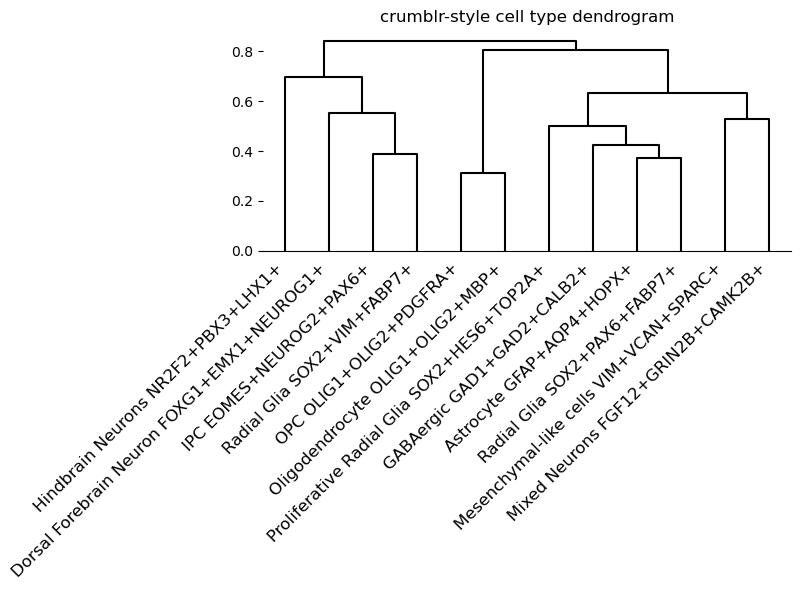

In [6]:
# 1. Load crumblr matrix (your bgm object)

# rows = cell types
# cols = samples

X = bgm.copy()

# ensure numeric
X = X.apply(pd.to_numeric)

# Match crumblr standardize()

# calculate z-score across samples like crumblr::standardize() does
X_std = (X.sub(X.mean(axis=1), axis=0)
           .div(X.std(axis=1).replace(0, np.nan), axis=0))

X_std = X_std.fillna(0)

# 3. Correlation BETWEEN CELL TYPES; Note: cell types are rows → correlate across samples
corr = np.corrcoef(X_std.values)

# Distance matrix 
dist = 1 - np.abs(corr)

# clean diagonal
np.fill_diagonal(dist, 0)

# Hierarchical clustering
Z = linkage(squareform(dist), method="average")

plt.figure(figsize=(8, 6))

dendrogram(
    Z,
    labels=X.index,
    leaf_rotation=45,
    color_threshold=0,
    link_color_func=lambda k: "black"
)

ax = plt.gca()

# control alignment
plt.setp(ax.get_xticklabels(), ha='right')

plt.title("crumblr-style cell type dendrogram")
plt.tight_layout()
sns.despine(left=True, bottom=False)
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Figure_crumblr_celltype_dendrogram.svg", dpi=500, bbox_inches="tight")
plt.show()

In [7]:
order = leaves_list(Z)

ordered_celltypes = X.index[order]

ordered_celltypes

Index(['Hindbrain Neurons NR2F2+PBX3+LHX1+',
       'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
       'IPC EOMES+NEUROG2+PAX6+', 'Radial Glia SOX2+VIM+FABP7+',
       'OPC OLIG1+OLIG2+PDGFRA+', 'Oligodendrocyte OLIG1+OLIG2+MBP+',
       'Proliferative Radial Glia SOX2+HES6+TOP2A+',
       'GABAergic GAD1+GAD2+CALB2+', 'Astrocyte GFAP+AQP4+HOPX+',
       'Radial Glia SOX2+PAX6+FABP7+',
       'Mesenchymal-like cells VIM+VCAN+SPARC+',
       'Mixed Neurons FGF12+GRIN2B+CAMK2B+'],
      dtype='object')

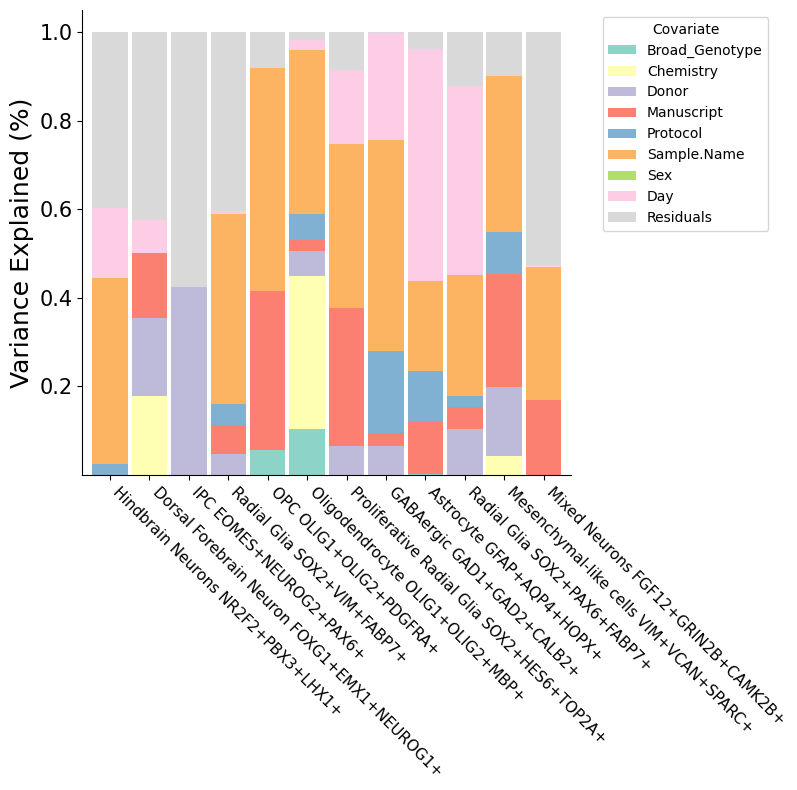

In [8]:
## Variance Partition Plot for Subclass Level Crumblr ##

# Color palette (one color per covariate)
palette = sns.color_palette("Set3", n_colors=bg.shape[1])

# Optional: reorder rows if desired
# bg = bg.loc[celltype_order]

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Plot
bg.loc[ordered_celltypes].plot(
    kind="bar",
    stacked=True,
    color=palette,
    ax=ax,
    width=0.9
)

# Labels
#ax.set_xlabel("Cell Type", fontsize=18)
ax.set_ylabel("Variance Explained (%)", fontsize=18)
#ax.set_title("Variance Explained by Covariates", fontsize=18)

# Rotate x labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha="left")

# Remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tick font sizes
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=15)

# Legend outside
ax.legend(
    title="Covariate",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    ncol=1
)

plt.tight_layout()

# Save
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Figure_crumblr_celltype_stacked_barplot.svg", dpi=500, bbox_inches="tight")
plt.show()

/tmp/ipykernel_382324/3211656079.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha="left")
/tmp/ipykernel_382324/3211656079.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


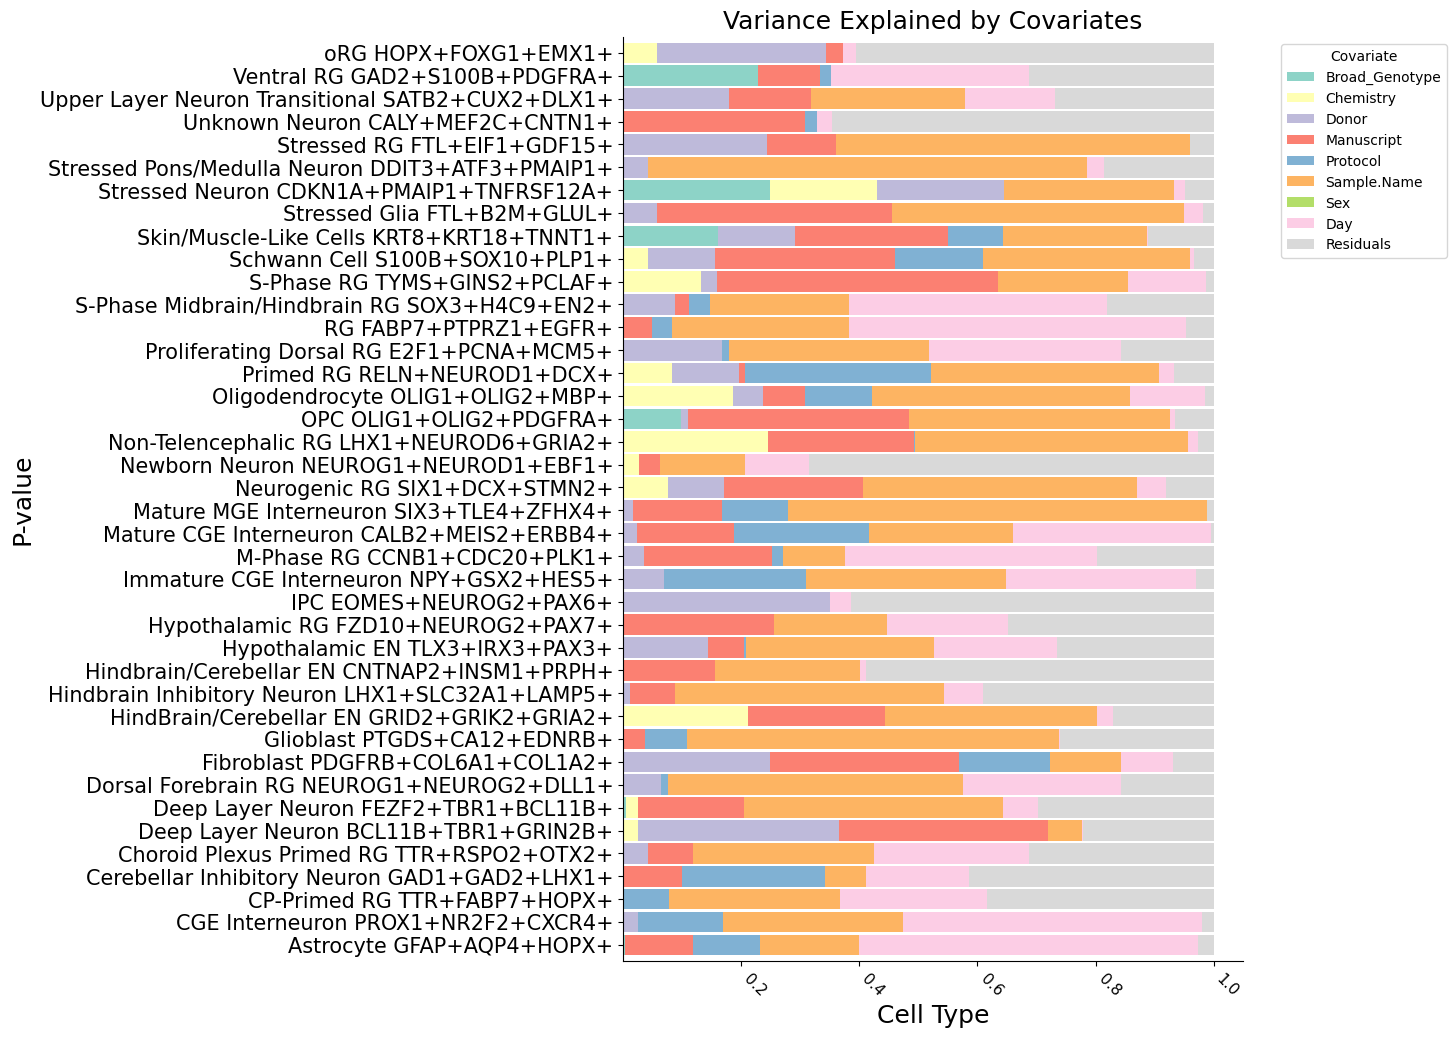

In [9]:
## Variance Partition Plot for Subclass Level Crumblr ##

# Color palette (one color per covariate)
palette = sns.color_palette("Set3", n_colors=bg_st.shape[1])

# Optional: reorder rows if desired
# bg_st = bg_st.loc[celltype_order]

# Create figure
fig, ax = plt.subplots(figsize=(8, 12))

# Plot
bg_st.plot(
    kind="barh",
    stacked=True,
    color=palette,
    ax=ax,
    width=0.9
)

# Labels
ax.set_xlabel("Cell Type", fontsize=18)
ax.set_ylabel("P-value", fontsize=18)
ax.set_title("Variance Explained by Covariates", fontsize=18)

# Rotate x labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha="left")

# Remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tick font sizes
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=15)

# Legend outside
ax.legend(
    title="Covariate",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    ncol=1
)

plt.tight_layout()

# Save
# plt.savefig("bg_st_stacked_barplot.svg", dpi=500, bbox_inches="tight")

plt.show()

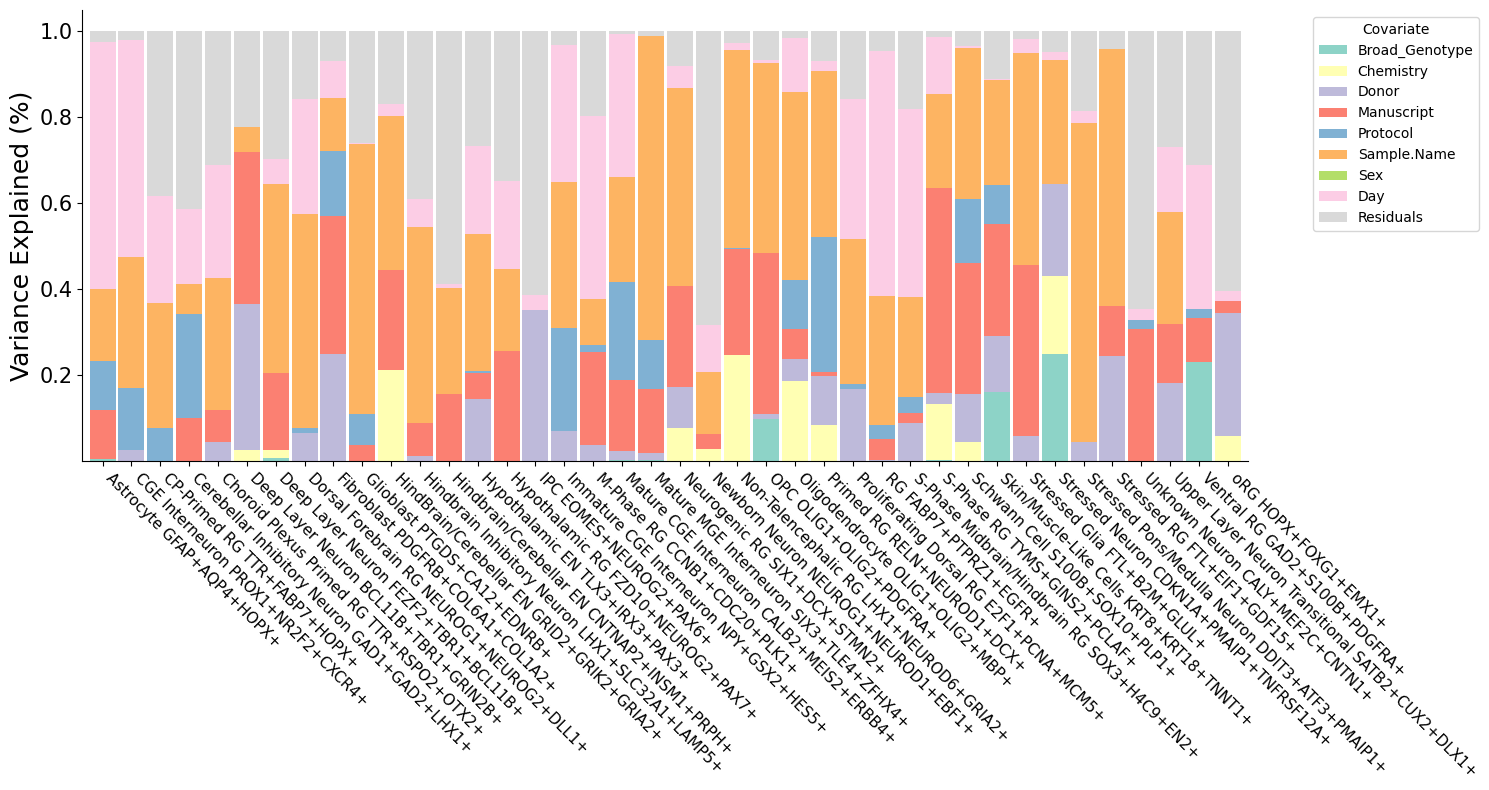

In [10]:
## Variance Partition Plot for Subclass Level Crumblr ##

# Color palette (one color per covariate)
palette = sns.color_palette("Set3", n_colors=bg_st.shape[1])

# Optional: reorder rows if desired
# bg = bg.loc[celltype_order]

# Create figure
fig, ax = plt.subplots(figsize=(15, 8))

# Plot
bg_st.plot(
    kind="bar",
    stacked=True,
    color=palette,
    ax=ax,
    width=0.9
)

# Labels
ax.set_ylabel("Variance Explained (%)", fontsize=18)

# Rotate x labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha="left")

# Remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tick font sizes
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=15)

# Legend outside
ax.legend(
    title="Covariate",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    ncol=1
)

plt.tight_layout()

# Save
#plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Figure_crumblr_celltype_stacked_barplot.svg", dpi=500, bbox_inches="tight")
plt.show()

In [11]:
celltype_crumblr_logfc = pd.concat([
    x22q11[['logFC']].rename(columns={'logFC': '22q11.2del'}),
    nrnxn1[['logFC']].rename(columns={'logFC': 'NRXN1del'}),
    x3q29[['logFC']].rename(columns={'logFC': '3q29del'}),
    x15q13[['logFC']].rename(columns={'logFC': '15q13.3del'}),
    idiopathic[['logFC']].rename(columns={'logFC': 'Idiopathic'})
], axis=1)

In [12]:
celltype_crumblr_p = pd.concat([
    x22q11[['adj.P.Val']].rename(columns={'adj.P.Val': '22q11.2del'}),
    nrnxn1[['adj.P.Val']].rename(columns={'adj.P.Val': 'NRXN1del'}),
    x3q29[['adj.P.Val']].rename(columns={'adj.P.Val': '3q29del'}),
    x15q13[['adj.P.Val']].rename(columns={'adj.P.Val': '15q13.3del'}),
    idiopathic[['adj.P.Val']].rename(columns={'adj.P.Val': 'Idiopathic'})
], axis=1)

In [13]:
dfs_celltype = {
    "22q11": x22q11,
    "NRXN1": nrnxn1,
    "3q29": x3q29,
    "15q13": x15q13,
    "Idiopathic": idiopathic,
}

plot_df_celltype = []

for disease, df in dfs_celltype.items():
    tmp = df.copy()
    tmp["CellType"] = tmp.index
    tmp["Disease"] = disease
    plot_df_celltype.append(tmp)

plot_df_celltype = pd.concat(plot_df_celltype, ignore_index=True)

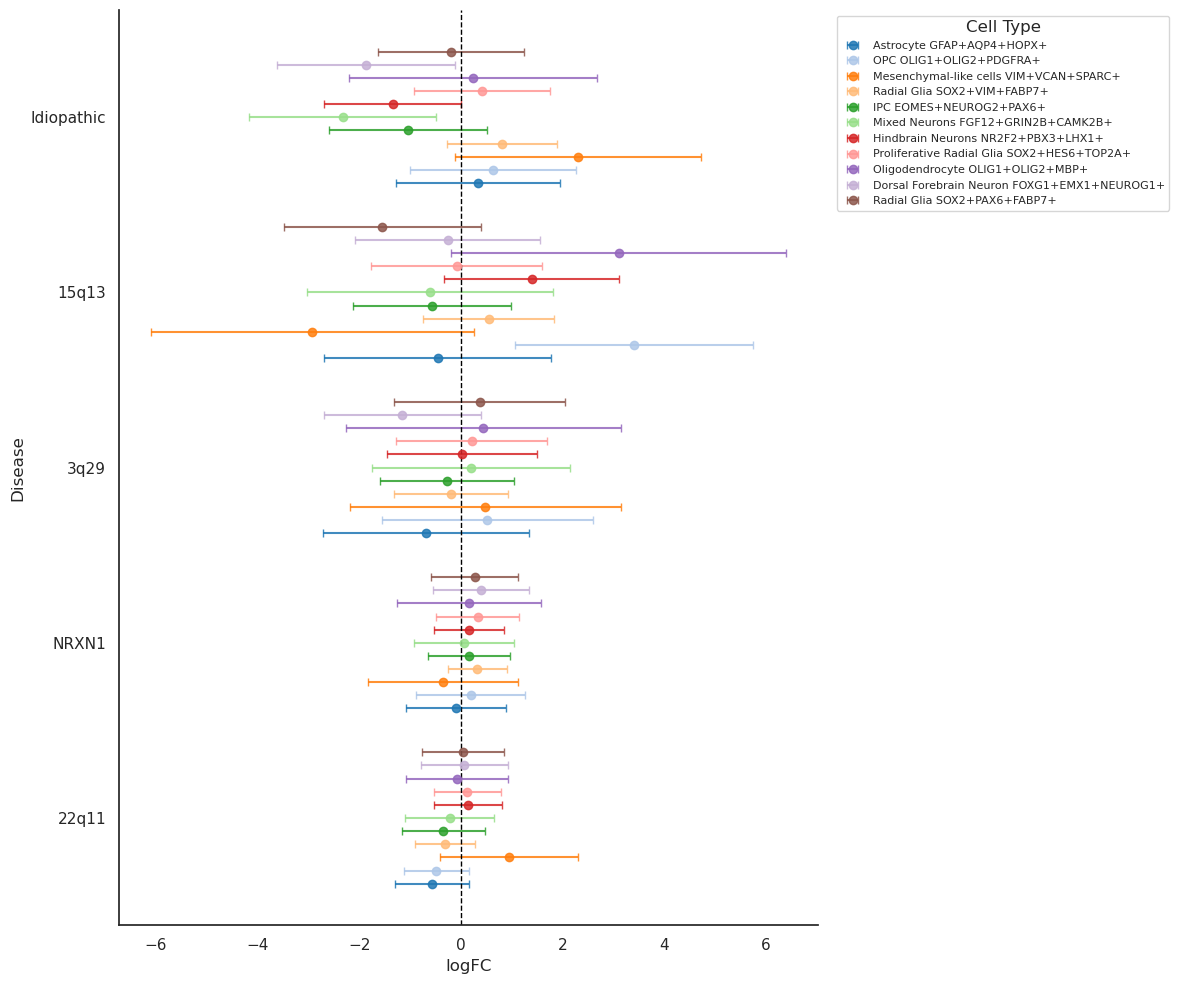

In [14]:
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(12, 10))

disease_order = ["22q11", "NRXN1", "3q29", "15q13", "Idiopathic"]
celltypes = plot_df_celltype["CellType"].unique()

disease_spacing = 10
cell_spacing = 0.75

palette = sns.color_palette("tab20", len(celltypes))

offsets = np.linspace(
    -cell_spacing * (len(celltypes) - 1) / 2,
     cell_spacing * (len(celltypes) - 1) / 2,
    len(celltypes)
)

for celltype, offset, color in zip(celltypes, offsets, palette):

    subdf = plot_df_celltype[plot_df_celltype["CellType"] == celltype]

    y = disease_spacing * np.array(
        [disease_order.index(d) for d in subdf["Disease"]]
    ) + offset

    ax.errorbar(
        subdf["logFC"],   # x-axis stays effect size
        y,                # disease axis
        xerr=subdf["CI95"],  # stays horizontal
        fmt="o",
        color=color,
        capsize=3,
        alpha=0.85,
        label=celltype
    )

ax.set_yticks(disease_spacing * np.arange(len(disease_order)))
ax.set_yticklabels(disease_order)

ax.axvline(0, color="black", linestyle="--", lw=1)

ax.set_xlabel("logFC")
ax.set_ylabel("Disease")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Cell Type",
    fontsize=8
)

plt.tight_layout()
plt.show()

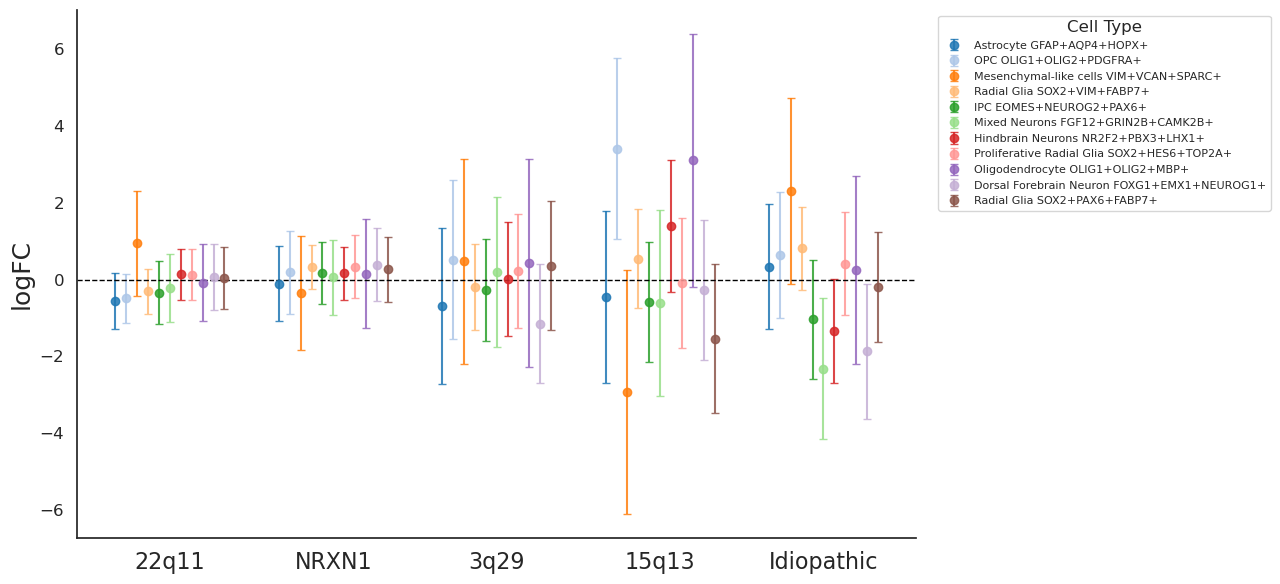

In [15]:
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(13, 6))

disease_order = ["22q11", "NRXN1", "3q29", "15q13", "Idiopathic"]
celltypes = plot_df_celltype["CellType"].unique()

disease_spacing = 30
cell_spacing = 2

palette = sns.color_palette("tab20", len(celltypes))

offsets = np.linspace(
    -cell_spacing * (len(celltypes) - 1) / 2,
     cell_spacing * (len(celltypes) - 1) / 2,
    len(celltypes)
)

for celltype, offset, color in zip(celltypes, offsets, palette):

    subdf = plot_df_celltype[plot_df_celltype["CellType"] == celltype]

    y = disease_spacing * np.array(
        [disease_order.index(d) for d in subdf["Disease"]]
    ) + offset

    ax.errorbar(
        y,                     # x-axis now = disease positions
        subdf["logFC"],       # y-axis now = effect size
        yerr=subdf["CI95"],   # CI follows y (logFC)
        fmt="o",
        color=color,
        capsize=3,
        alpha=0.85,
        label=celltype
    )

# ---- axis formatting flipped ----
ax.set_xticks(disease_spacing * np.arange(len(disease_order)))
ax.set_xticklabels(disease_order)

ax.axhline(0, color="black", linestyle="--", lw=1)

ax.set_ylabel("logFC", fontsize=18)
#ax.set_xlabel("Disease", fontsize=16)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Cell Type",
    fontsize=8
)

plt.tight_layout()
plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Supplementary_Figure_crumblr_celltype_lineplot.svg", dpi=500, bbox_inches="tight")
plt.show()

In [16]:
dfs_celltype_st = {
    "22q11": x22q11_st,
    "NRXN1": nrnxn1_st,
    "3q29": x3q29_st,
    "15q13": x15q13_st,
    "Idiopathic": idiopathic_st,
}

plot_df_celltype_st = []

for disease, df in dfs_celltype_st.items():
    tmp = df.copy()
    tmp["CellType"] = tmp.index
    tmp["Disease"] = disease
    plot_df_celltype_st.append(tmp)

plot_df_celltype_st = pd.concat(plot_df_celltype_st, ignore_index=True)